In [9]:
import os
import numpy as np
import pandas as pd
import sys
from pathlib import Path
from src.prometheus_io import prom_query_range, prom_query_instant, test_connection
import src.prometheus_io as pio
from datetime import datetime, timezone, timedelta
import matplotlib.pyplot as plt

In [14]:
df_monolith = pd.read_csv('../exports/intensive_messaging_monolith_newest.csv')
df_eda = pd.read_csv('../exports/intensive_messaging_eda_newest.csv')

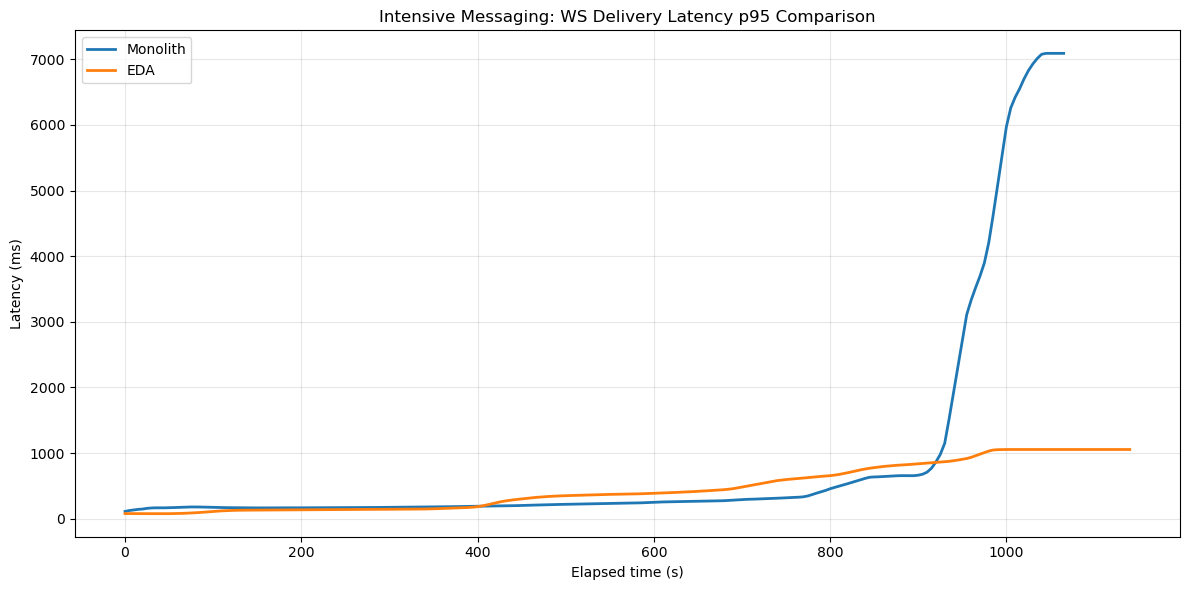

Using monolith latency column: ws_lat__k6_ws_delivery_latency_ms_p95 {'scenario': 'ws_receivers'}
Using EDA latency column: ws_lat__k6_ws_delivery_latency_ms_p95 {'scenario': 'ws_receivers'}
Monolith start: 2026-05-13 09:35:16.630000114+00:00, EDA start: 2026-05-12 17:51:16.953000069+00:00


In [15]:
latency_col_candidates_monolith = [c for c in df_monolith.columns if "ws_lat__k6_ws_delivery_latency_ms_p95" in c]
latency_col_candidates_eda = [c for c in df_eda.columns if "ws_lat__k6_ws_delivery_latency_ms_p95" in c]

if not latency_col_candidates_monolith:
    raise ValueError("Could not find ws latency p95 column in df_monolith")
if not latency_col_candidates_eda:
    raise ValueError("Could not find ws latency p95 column in df_eda")

lat_col_monolith = latency_col_candidates_monolith[0]
lat_col_eda = latency_col_candidates_eda[0]

mono = (
    df_monolith[["timestamp", lat_col_monolith]]
    .rename(columns={lat_col_monolith: "latency_ms"})
    .copy()
)
eda = (
    df_eda[["timestamp", lat_col_eda]]
    .rename(columns={lat_col_eda: "latency_ms"})
    .copy()
)

mono["timestamp"] = pd.to_datetime(mono["timestamp"], errors="coerce", utc=True)
eda["timestamp"] = pd.to_datetime(eda["timestamp"], errors="coerce", utc=True)

mono["latency_ms"] = pd.to_numeric(mono["latency_ms"], errors="coerce")
eda["latency_ms"] = pd.to_numeric(eda["latency_ms"], errors="coerce")

mono = mono.dropna(subset=["timestamp", "latency_ms"]).sort_values("timestamp")
eda = eda.dropna(subset=["timestamp", "latency_ms"]).sort_values("timestamp")

# Align both runs to t=0 by using elapsed seconds from each run's start
mono_start = mono["timestamp"].min()
eda_start = eda["timestamp"].min()
mono["elapsed_s"] = (mono["timestamp"] - mono_start).dt.total_seconds()
eda["elapsed_s"] = (eda["timestamp"] - eda_start).dt.total_seconds()

# Smoothing
mono["latency_ms_smooth"] = mono["latency_ms"].rolling(window=5, min_periods=1).mean()
eda["latency_ms_smooth"] = eda["latency_ms"].rolling(window=5, min_periods=1).mean()

plt.figure(figsize=(12, 6))
plt.plot(mono["elapsed_s"], mono["latency_ms_smooth"], label="Monolith", linewidth=2)
plt.plot(eda["elapsed_s"], eda["latency_ms_smooth"], label="EDA", linewidth=2)

plt.title("Intensive Messaging: WS Delivery Latency p95 Comparison")
plt.xlabel("Elapsed time (s)")
plt.ylabel("Latency (ms)")
plt.legend()
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()

print(f"Using monolith latency column: {lat_col_monolith}")
print(f"Using EDA latency column: {lat_col_eda}")
print(f"Monolith start: {mono_start}, EDA start: {eda_start}")